In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mohammedalrajeh/quran-recitations-for-audio-classification")

Skipping, found downloaded files in "./quran-recitations-for-audio-classification" (use force=True to force download)


In [2]:
import torch
from torch import nn
from torch.optim import Adam
import librosa
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import os
import time
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
df = pd.read_csv('/content/quran-recitations-for-audio-classification/files_paths.csv')
print(f"Classes : {df["Class"].unique()}")
print()
print('Number of Classes : ',len(df['Class'].unique()))
df.head()


Classes : ['Mohammed_Aluhaidan' 'Yasser_Aldossary' 'Maher_Almuaiqly'
 'Nasser_Alqutami' 'AbdulBari_Althubaity' 'Bander_Balilah'
 'Ali_Alhothaify' 'Saud_Alshuraim' 'Mohammed_Ayoub' 'AbdulRahman_Alsudais'
 'Saad_Alghamdi' 'Abdullah_Albuaijan']

Number of Classes :  12


,FilePath,Class
0,./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav,Mohammed_Aluhaidan
1,./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav,Mohammed_Aluhaidan
2,./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav,Mohammed_Aluhaidan
3,./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav,Mohammed_Aluhaidan
4,./Dataset/Mohammed_Aluhaidan/lohaidan_373.wav,Mohammed_Aluhaidan


path ex : `/content/quran-recitations-for-audio-classification/Dataset/Dataset/AbdulBari_Althubaity/abdulbari_001.wav`

In [4]:
df['FilePath'] = "/content/quran-recitations-for-audio-classification/Dataset" + df['FilePath'].str[1:]
print(df['FilePath'][0])


/content/quran-recitations-for-audio-classification/Dataset/Dataset/Mohammed_Aluhaidan/lohaidan_171.wav


In [5]:
print(f"Data shape : {df.shape}")
print(f"Number of classes : {len(df['Class'].unique())}")
print(f"Data distribution : \n{df['Class'].value_counts()}")

Data shape : (6687, 2)
Number of classes : 12
Data distribution : 
Class
Saud_Alshuraim          696
Saad_Alghamdi           688
AbdulRahman_Alsudais    648
Yasser_Aldossary        576
Ali_Alhothaify          576
Bander_Balilah          576
Maher_Almuaiqly         576
Abdullah_Albuaijan      504
Mohammed_Ayoub          480
Nasser_Alqutami         456
AbdulBari_Althubaity    456
Mohammed_Aluhaidan      455
Name: count, dtype: int64


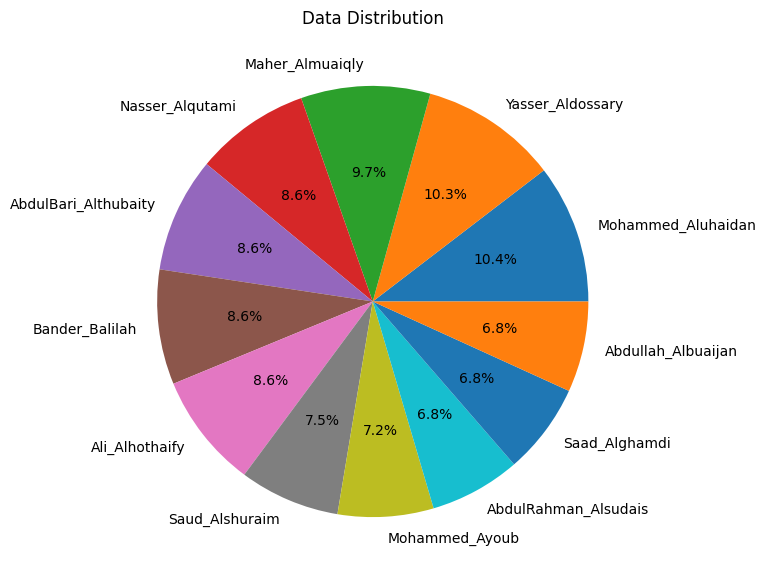

In [6]:
plt.figure(figsize=(10, 7))
plt.pie(df['Class'].value_counts(), labels=df['Class'].unique(), autopct='%1.1f%%')
plt.title('Data Distribution')
plt.show()

In [7]:
## splitting the data train 70% -- val 15% -- test 15%


train = df.sample(frac = 0.7, random_state=42)
test = df.drop(train.index)
val = test.sample(frac = 0.5, random_state=42)
test = test.drop(val.index)

print(f"Train shape : {train.shape}")
print(f"Val shape : {val.shape}")
print(f"Test shape : {test.shape}")

Train shape : (4681, 2)
Val shape : (1003, 2)
Test shape : (1003, 2)


In [8]:
label_encoder = LabelEncoder()

class Data(Dataset):
  def __init__(self, df):
    self.df = df
    self.labels = torch.tensor(label_encoder.fit_transform(df['Class']), dtype=torch.long)
    self.audios = [torch.Tensor(self.get_specrogram(path)).unsqueeze(0).type(torch.FloatTensor) for path in df['FilePath']]

  def __len__(self):
    return self.df.shape[0]

  def __getitem__(self, idx):
    audio = self.audios[idx].to(device)
    label = self.labels[idx].to(device)
    return audio, label

  def get_specrogram(self, path):
    sr = 22050
    duration = 5

    img_height = 128
    img_width = 256

    signal, sr = librosa.load(path, sr=sr, duration=duration)

    spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
    spec_db = librosa.power_to_db(spec, ref=np.max)
    spec_resized = librosa.util.fix_length(spec_db, size=(duration * sr) // 512 + 1)
    spec_resized = resize(spec_resized, (img_height, img_width), anti_aliasing=True)
    return spec_resized

In [9]:
train_data = Data(train)
val_data = Data(val)
test_data = Data(test)
print(f"Train shape : {len(train_data)}")
print(f"Val shape : {len(val_data)}")
print(f"Test shape : {len(test_data)}")

Train shape : 4681
Val shape : 1003
Test shape : 1003


In [10]:
LR = 1e-3
BATCH_SIZE = 64
EPOCHS = 15

In [11]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
class Zen(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
    self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
    self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
    self.pooling = nn.MaxPool2d(kernel_size=2, stride=2)
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()

    self.linear1 = nn.Linear(in_features=64*16*32, out_features=4096)
    self.linear2 = nn.Linear(in_features=4096, out_features=2048)
    self.linear3 = nn.Linear(in_features=2048, out_features=1024)
    self.linear4 = nn.Linear(in_features=1024, out_features=512)

    self.output = nn.Linear(in_features=512, out_features=len(df['Class'].unique()))

    self.dropout = nn.Dropout(0.4)

  def forward(self, X):
    X = self.relu(self.conv1(X))
    X = self.pooling(X)

    X = self.relu(self.conv2(X))
    X = self.pooling(X)

    X = self.relu(self.conv3(X))
    X = self.pooling(X)

    X = self.flatten(X)

    X = self.relu(self.linear1(X))
    X = self.dropout(X)

    X = self.relu(self.linear2(X))
    X = self.dropout(X)

    X = self.relu(self.linear3(X))
    X = self.dropout(X)

    X = self.relu(self.linear4(X))
    X = self.dropout(X)

    X = self.output(X)

    return X

model = Zen().to(device)

In [13]:
from torchsummary import summary
summary(model, (1, 128, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
              ReLU-2         [-1, 16, 128, 256]               0
         MaxPool2d-3          [-1, 16, 64, 128]               0
            Conv2d-4          [-1, 32, 64, 128]           4,640
              ReLU-5          [-1, 32, 64, 128]               0
         MaxPool2d-6           [-1, 32, 32, 64]               0
            Conv2d-7           [-1, 64, 32, 64]          18,496
              ReLU-8           [-1, 64, 32, 64]               0
         MaxPool2d-9           [-1, 64, 16, 32]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                 [-1, 4096]     134,221,824
             ReLU-12                 [-1, 4096]               0
          Dropout-13                 [-1, 4096]               0
           Linear-14                 [-

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(params=model.parameters(), lr=LR)

In [15]:
total_train_loss_plot = []
total_train_acc_plot = []
total_val_loss_plot = []
total_val_acc_plot = []

start = time.time()

for epoch in range(EPOCHS):
  total_acc_train, total_loss_train, total_loss_val, total_acc_val = 0, 0, 0, 0

  model.train()
  for inputs, labels in train_loader:
    outputs = model(inputs)

    train_loss = loss_fn(outputs, labels)
    total_loss_train += train_loss.item()

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
    total_acc_train += train_acc

  model.eval()
  with torch.inference_mode():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = loss_fn(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
      total_acc_val += val_acc

  total_train_loss_plot.append(round(total_loss_train/len(train_data), 4))
  total_train_acc_plot.append(round(total_acc_train/len(train_data)*100, 4))

  total_val_loss_plot.append(round(total_loss_val/len(val_data), 4))
  total_val_acc_plot.append(round(total_acc_val/len(val_data)*100, 4))

  print(f"Epoch : {epoch+1} | "
      f"Train Loss : {total_train_loss_plot[-1]} | "
      f"Train Accuracy : {total_train_acc_plot[-1]} | "
      f"Validation Loss : {total_val_loss_plot[-1]} | "
      f"Validation Acc : {total_val_acc_plot[-1]}")

end = time.time()
print(f"Training took {round(end - start, 2)} seconds")

Epoch : 1 | Train Loss : 0.0407 | Train Accuracy : 11.7283 | Validation Loss : 0.0376 | Validation Acc : 17.348
Epoch : 2 | Train Loss : 0.0283 | Train Accuracy : 35.5907 | Validation Loss : 0.021 | Validation Acc : 55.4337
Epoch : 3 | Train Loss : 0.0179 | Train Accuracy : 61.6535 | Validation Loss : 0.0139 | Validation Acc : 69.8903
Epoch : 4 | Train Loss : 0.0132 | Train Accuracy : 72.3991 | Validation Loss : 0.0105 | Validation Acc : 78.0658
Epoch : 5 | Train Loss : 0.0101 | Train Accuracy : 78.9575 | Validation Loss : 0.0091 | Validation Acc : 80.658
Epoch : 6 | Train Loss : 0.0093 | Train Accuracy : 80.6879 | Validation Loss : 0.0093 | Validation Acc : 82.9511
Epoch : 7 | Train Loss : 0.0069 | Train Accuracy : 86.1995 | Validation Loss : 0.008 | Validation Acc : 84.7458
Epoch : 8 | Train Loss : 0.0055 | Train Accuracy : 88.8913 | Validation Loss : 0.0054 | Validation Acc : 90.5284
Epoch : 9 | Train Loss : 0.0052 | Train Accuracy : 90.1944 | Validation Loss : 0.0055 | Validation A

In [16]:
model.eval()
with torch.inference_mode():
  total_acc_test, total_loss_test = 0, 0
  for inputs, labels in test_loader:
    outputs = model(inputs)
    test_loss = loss_fn(outputs, labels)
    total_loss_test += test_loss.item()

    test_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
    total_acc_test += test_acc

  print(f"Test Loss : {round(total_loss_test/len(test_data), 4)} | "
      f"Test Acc : {round(total_acc_test/len(test_data)*100, 4)}")

Test Loss : 0.0053 | Test Acc : 91.2263


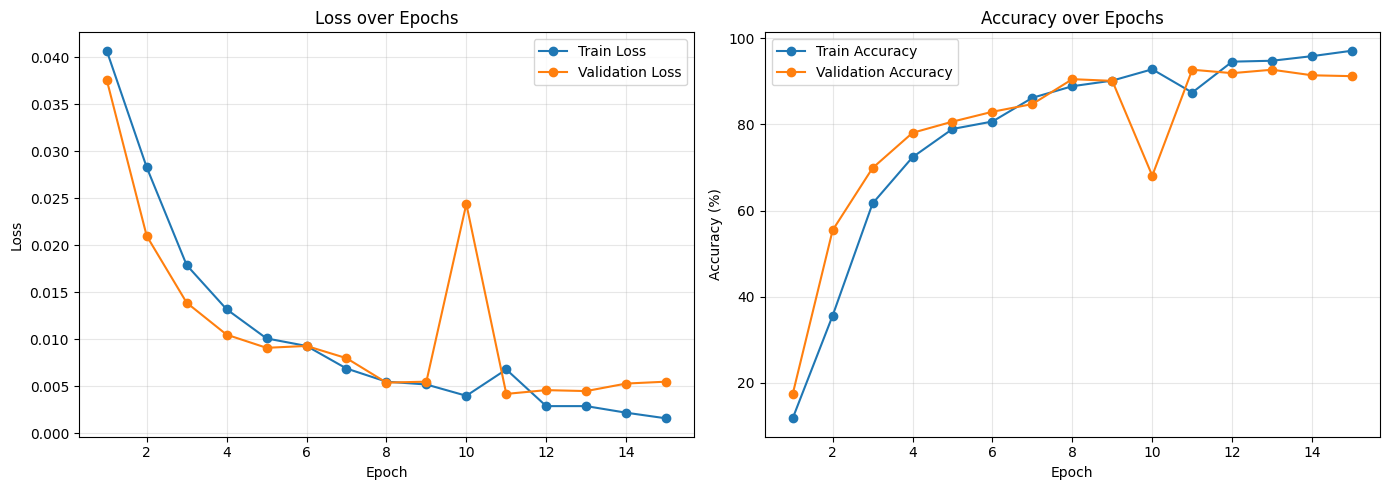

Final Train Loss: 0.0016 | Final Train Accuracy: 97.1374%
Final Validation Loss: 0.0055 | Final Validation Accuracy: 91.2263%
Best Validation Accuracy: 92.7218% (Epoch 11)


In [18]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(total_train_loss_plot) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, total_train_loss_plot, label='Train Loss', marker='o')
axes[0].plot(epochs_range, total_val_loss_plot, label='Validation Loss', marker='o')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, total_train_acc_plot, label='Train Accuracy', marker='o')
axes[1].plot(epochs_range, total_val_acc_plot, label='Validation Accuracy', marker='o')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Train Loss: {total_train_loss_plot[-1]} | Final Train Accuracy: {total_train_acc_plot[-1]}%")
print(f"Final Validation Loss: {total_val_loss_plot[-1]} | Final Validation Accuracy: {total_val_acc_plot[-1]}%")
print(f"Best Validation Accuracy: {max(total_val_acc_plot)}% (Epoch {total_val_acc_plot.index(max(total_val_acc_plot)) + 1})")